In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
df = pd.read_csv("solar_system-Copy2.csv")
print(df.shape)
print(df.head())
print(df.tail())
print(df.columns)
print(df.index)

(20, 11)
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring Sy

In [5]:
orbital_period = df.iloc[8, 1:].astype(float)
perihelion = df.iloc[10, 1:].astype(float)
aphelion = df.iloc[11, 1:].astype(float)

- orbital period: the time it takes for a planet to make one revolution (go around) about the Sun.
- perihelion: the point in the elliptical orbit that is closest to the Sun
- aphelion: the point in the orbit that is furthest from the Sun

In [7]:
semi_major_axis = (perihelion + aphelion) / 2
new_row_data = {col: val for col, val in zip(df.columns[1:], semi_major_axis.values)}
new_row_data['Attribute'] = 'Semi-major axis (10^6 km)'
new_row_series = pd.Series(new_row_data)
new_row_df = new_row_series.to_frame().T
df = pd.concat([df, new_row_df], ignore_index=True)

In [8]:
print(df.tail())
print(df.shape)

                    Attribute Mercury   Venus  Earth   Moon    Mars  Jupiter  \
16    Surface Pressure (bars)       0      92      1      0    0.01  Unknown   
17            Number of Moons       0       0      1      0       2       95   
18               Ring System?      No      No     No     No      No      Yes   
19     Global Magnetic Field?     Yes      No    Yes     No      No      Yes   
20  Semi-major axis (10^6 km)    67.7  129.85  197.5  14.15  355.55  2172.05   

     Saturn   Uranus  Neptune     Pluto  
16  Unknown  Unknown  Unknown   0.00001  
17      274       28       16         5  
18      Yes      Yes      Yes        No  
19      Yes      Yes      Yes   Unknown  
20  5378.35  15297.9  29902.7  45282.35  
(21, 11)


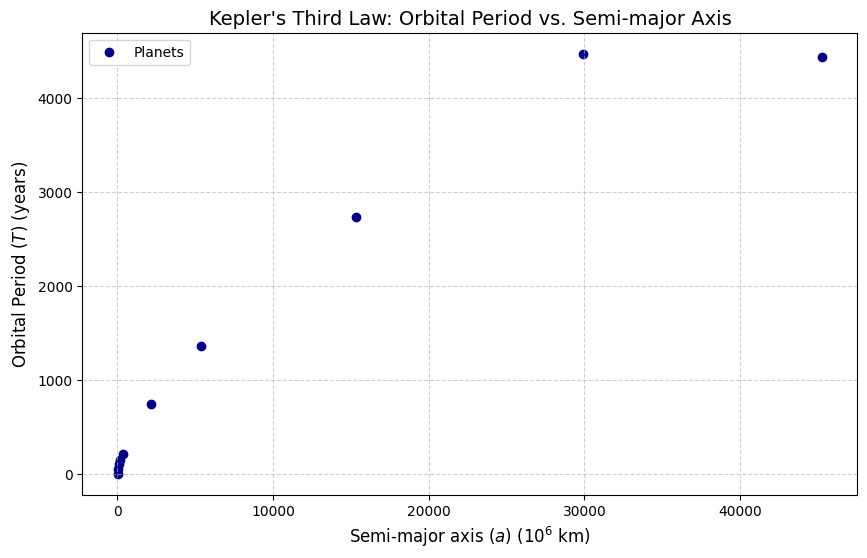

In [9]:
semi_major_axis = df.iloc[20, 1:].astype(float)
plt.figure(figsize=(10, 6))
plt.scatter(semi_major_axis, orbital_period, label='Planets', color='darkblue')

plt.xlabel("Semi-major axis ($a$) ($10^6$ km)", fontsize=12)
plt.ylabel("Orbital Period ($T$) (years)", fontsize = 12)
plt.title("Kepler's Third Law: Orbital Period vs. Semi-major Axis", fontsize = 14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
def keplers_third_law(a, m):
    return m * a**1.5

In [21]:
#fixing scale mismatch
earth_semi_major_axis_val = df.iloc[20]['Earth'].astype(float)
semi_major_axis_AU = semi_major_axis / earth_semi_major_axis_val

In [22]:
p0 = [1]
popt, pcov = curve_fit(keplers_third_law, semi_major_axis_AU, orbital_period, p0=p0)
m_fit = popt[0]
print(f"Fit: T = {m_fit:.2f} * a^1.5")

Fit: T = 1.61 * a^1.5


In [23]:
residuals = orbital_period - keplers_third_law(semi_major_axis_AU, m_fit)
chi2 = np.sum(residuals**2)
dof = len(orbital_period) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced Chi-Squared: {chi2_reduced:.4f}")

Reduced Chi-Squared: 886988.9785


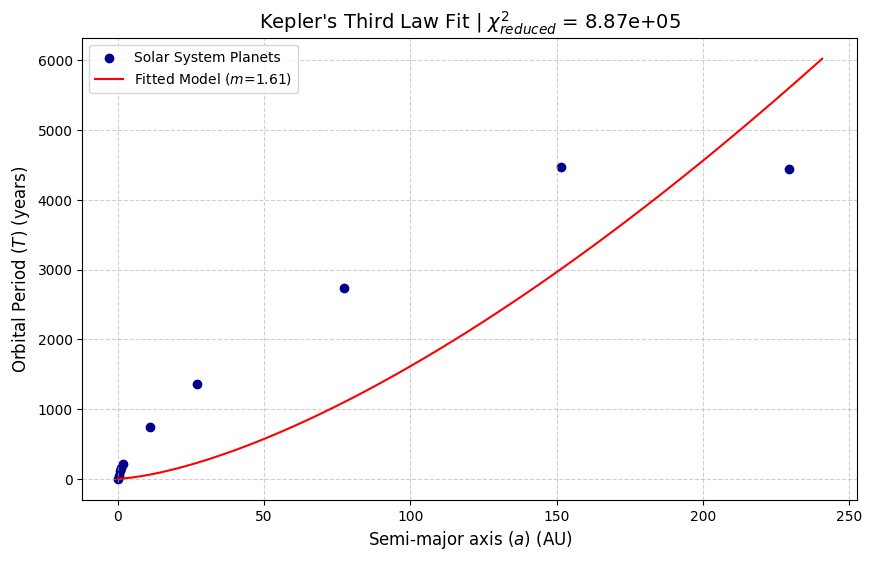

In [25]:
a_fit_line = np.linspace(0, semi_major_axis_AU.max() * 1.05, 100)
T_fit_line = keplers_third_law(a_fit_line, m_fit)

plt.figure(figsize=(10,6))
plt.scatter(semi_major_axis_AU, orbital_period, color='darkblue', label='Solar System Planets')
plt.plot(a_fit_line, T_fit_line, color='red', linestyle='-', label=f"Fitted Model ($m$={m_fit:.2f})")
plt.xlabel("Semi-major axis ($a$) (AU)", fontsize=12)
plt.ylabel("Orbital Period ($T$) (years)", fontsize=12)
plt.title(f"Kepler's Third Law Fit | $\chi^2_{{reduced}}$ = {chi2_reduced:.2e}", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
#this looks wrong but........idk

In [26]:
df.to_csv("kepler.csv", index=False)